In [55]:
# ────────────────────────────────────────────────
#          Cell 1 – Imports & Device
# ────────────────────────────────────────────────

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  # or just to(device) if using GPU
print(f"Using device: {device}")

Using device: cuda


In [56]:
# ────────────────────────────────────────────────
#          Cell 2 – Load model & tokenizer
# ────────────────────────────────────────────────

# Change this path to your fine-tuned model
MODEL_PATH = "H:\\AIML_project\\Model_desgin\\server_trained\\roberta-fake-news-cleaned-best"          # ← your folder here

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH,
    output_attentions=True
)

# …
model.to(device).to(torch.float32) # Ensure model is in float32 for inference (some models may be in float16 or bfloat16)

model.eval()

print("Model loaded ✓")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1180.29it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              


Model loaded ✓


In [57]:
# ────────────────────────────────────────────────
#          Cell 3 – Prediction function
# ────────────────────────────────────────────────

def predict(text, return_details=False):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    probs = torch.softmax(logits, dim=-1)[0].cpu().numpy()
    
    pred_class = int(np.argmax(probs))
    confidence = float(probs[pred_class])
    
    if not return_details:
        return pred_class, confidence
    
    return pred_class, confidence, probs, inputs

In [58]:
# ────────────────────────────────────────────────
#     Cell 4 – Simple colored prediction display
# ────────────────────────────────────────────────

def show_prediction(text):
    cls, conf, probs, _ = predict(text, return_details=True)
    
    label = "FAKE" if cls == 1 else "REAL"
    color = "#e74c3c" if cls == 1 else "#2ecc71"
    
    html = f"""
    <div style="padding:16px; border-radius:8px; background:{color}20; border:2px solid {color};">
        <h2 style="margin:0; color:{color};">{label} – {conf:.1%}</h2>
        <div style="margin-top:12px;">
            <small>Real: {probs[0]:.1%} | Fake: {probs[1]:.1%}</small>
        </div>
    </div>
    """
    display(HTML(html))

In [59]:
# ────────────────────────────────────────────────
#          Cell 5 – Attention visualization
# ────────────────────────────────────────────────

def show_attention(text, layer=-1, head=-1, top_k_tokens=20):
    _, _, _, inputs = predict(text, return_details=True)
    
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
    
    # [batch, heads, seq_len, seq_len] → last layer, mean over heads or single head
    att = outputs.attentions[layer]              # shape: (1, nh, ntok, ntok)
    
    if head >= 0:
        att = att[:, head]                       # single head
    else:
        att = att.mean(dim=1)                    # average heads
    
    att = att[0].cpu().numpy()                   # (ntok, ntok)
    
    # Attention **from** CLS token (row 0)
    cls_att = att[0]
    
    # Get tokens (skip special)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    clean_tokens = [t.replace("Ġ","").replace("Â","") for t in tokens]
    
    # Filter special tokens
    valid_mask = ~np.isin(tokens, ["<s>","</s>","<pad>"])
    valid_tokens = [clean_tokens[i] for i in range(len(tokens)) if valid_mask[i]]
    valid_att    = cls_att[valid_mask]
    
    # Sort
    idx = np.argsort(valid_att)[::-1][:top_k_tokens]
    top_tokens = [valid_tokens[i] for i in idx]
    top_values = valid_att[idx]
    
    # ─── Bar plot ───
    plt.figure(figsize=(10, max(4, len(top_tokens)*0.35)))
    sns.barplot(x=top_values, y=top_tokens, palette="viridis")
    plt.title(f"Top tokens attended by CLS – layer {layer+1}")
    plt.xlabel("Attention weight")
    plt.tight_layout()
    plt.show()
    
    # Also show colored text (simple version)
    norm = valid_att / valid_att.max()
    parts = []
    for tok, v in zip(valid_tokens, norm):
        if v > 0.15:
            alpha = min(0.9, v*1.8)
            parts.append(f'<span style="background:rgba(76,175,80,{alpha:.2f}); padding:2px 5px; border-radius:4px;">{tok}</span>')
        else:
            parts.append(tok)
    
    display(HTML(" ".join(parts)))

In [60]:
# ────────────────────────────────────────────────
#                Usage examples
# ────────────────────────────────────────────────
# ────────────────────────────────────────────────
#     Remove only punctuation (no stop words)
# ────────────────────────────────────────────────

# import re

# def remove_only_punctuation(text):
#     # Keep: letters, digits, spaces, hyphens (high-speed), apostrophes (SUV's)
#     # Remove: everything else (commas, periods, parentheses, slashes, etc.)
#     cleaned = re.sub(r'[^\w\s\'-]', '', text)
    
#     # Optional: collapse multiple spaces into one and strip
#     cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    
#     return cleaned

# news is real
# Your original text
text = '''
AI Summit 2026 LIVE updates: The fifth and the conclusive day of the India AI Impact Summit 2025 will be marked by several key discussions, including on reimagining India's education system, the US-India partnership powering the AI era, AI in negotiations and diplomacy, data sovereignty, collective AI for Indian society, among many others.

On Friday, Brazil and its perspective on the future of AI will also be a key highlight as President Luiz Inácio Lula da Silva will address the summit along with several other ministers from Brazil.

The fifth day of the summit may also witness adoption of the Leaders’ Declaration which would affirm collective commitments and outlining a shared road map for global AI governance and collaboration.

High-level Global Partnership on Artificial Intelligence (GPAI) council meetings will also take place.

This comes a day after Prime Minister Narendra Modi addressed the summit on Thursday and sought to frame India as a key player in AI ecosystem. During his address, PM Modi called for stronger guardrails to regulate emerging technologies and underlined the transformative potential of AI. He also emphasized on key topics such as child safety, and called for more democratisation of artificial intelligence.

He also hosted several heads of state at the Summit on Thursday and also held a CEO Roundtable which brought together several stakeholders from the world of AI. "The discussions were insightful and forward-looking, focused on scaling AI responsibly, strengthening global collaboration and unlocking opportunities for growth," he said in a post on X.
'''

positive_tone_text = '''AI Summit 2026 LIVE: Final Day Focuses on Global Collaboration and India’s Leadership in AI

The fifth and concluding day of the India AI Impact Summit 2025 promises high-level discussions shaping the global AI landscape. Key sessions will explore reimagining India’s education system, strengthening the US–India partnership in the AI era, AI in diplomacy and negotiations, data sovereignty, and collective AI solutions for Indian society.

A major highlight includes Brazilian President Luiz Inácio Lula da Silva, who will present Brazil’s vision for the future of artificial intelligence. Several Brazilian ministers are also participating, reinforcing international cooperation.

Leaders are expected to adopt the “Leaders’ Declaration,” outlining a shared global roadmap for AI governance and collaboration. High-level meetings of the Global Partnership on Artificial Intelligence (GPAI) Council will further strengthen multilateral engagement.

On Thursday, Prime Minister Narendra Modi positioned India as a central force in the global AI ecosystem. He emphasized the transformative power of AI while advocating for stronger regulatory guardrails, child safety protections, and greater democratization of AI technologies.

The Prime Minister also hosted global leaders and chaired a CEO Roundtable, describing the discussions as “insightful and forward-looking,” focused on responsible scaling, collaboration, and growth.'''


negative_tone_text = '''AI Summit 2026 LIVE: Big Promises as Leaders Debate Regulation, Governance and AI Power Dynamics

The final day of the India AI Impact Summit 2025 features discussions on ambitious themes such as education reform, AI diplomacy, data sovereignty, and the US–India AI partnership. However, questions remain about how these broad commitments will translate into tangible outcomes.

Brazilian President Luiz Inácio Lula da Silva is set to present his country’s perspective on AI’s future, alongside Brazilian ministers. While international participation signals cooperation, skeptics argue that global AI governance still lacks enforceable mechanisms.

Leaders may adopt a “Leaders’ Declaration” outlining commitments and a roadmap for collaboration. Critics note that similar declarations in the past have struggled with implementation.

On Thursday, Prime Minister Narendra Modi framed India as a major AI player, calling for regulatory guardrails and stressing AI’s transformative potential. He highlighted issues such as child safety and democratization of AI, but analysts point out the complexities of balancing innovation with effective regulation.

A CEO Roundtable brought together industry leaders to discuss scaling AI responsibly, though concerns persist about corporate influence in shaping global AI policies.'''

neutral_tone_text = '''AI Summit 2026 LIVE: Final Day to Focus on Governance, Education and Global AI Partnerships

The fifth and concluding day of the India AI Impact Summit 2025 will feature discussions on several key topics, including reforms in India’s education system, the US–India AI partnership, AI in diplomacy and negotiations, data sovereignty, and collective AI initiatives for society.

Brazilian President Luiz Inácio Lula da Silva is scheduled to address the summit, presenting Brazil’s outlook on the future of artificial intelligence. Other Brazilian ministers will also participate.

The summit may see the adoption of a Leaders’ Declaration outlining shared commitments and a roadmap for global AI governance and collaboration. Meetings of the Global Partnership on Artificial Intelligence (GPAI) Council are also scheduled.

On Thursday, Prime Minister Narendra Modi addressed the summit, emphasizing India’s role in the AI ecosystem. He called for stronger regulatory frameworks, highlighted AI’s transformative potential, and stressed issues such as child safety and democratization. He also hosted heads of state and conducted a CEO Roundtable focused on responsible AI scaling and global cooperation.'''

In [61]:
import re

def remove_punctuation(text):
    # Remove most punctuation but keep hyphens in compounds and apostrophes
    text = re.sub(r'[^\w\s\'-]', '', text)  # keeps letters, digits, space, ', -
    text = re.sub(r'\s+', ' ', text).strip()  # clean extra spaces
    return text.lower()  # often helps too

C:\Users\GYANENDRA\AppData\Local\Temp\ipykernel_20716\2980508986.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_tokens, palette="viridis")


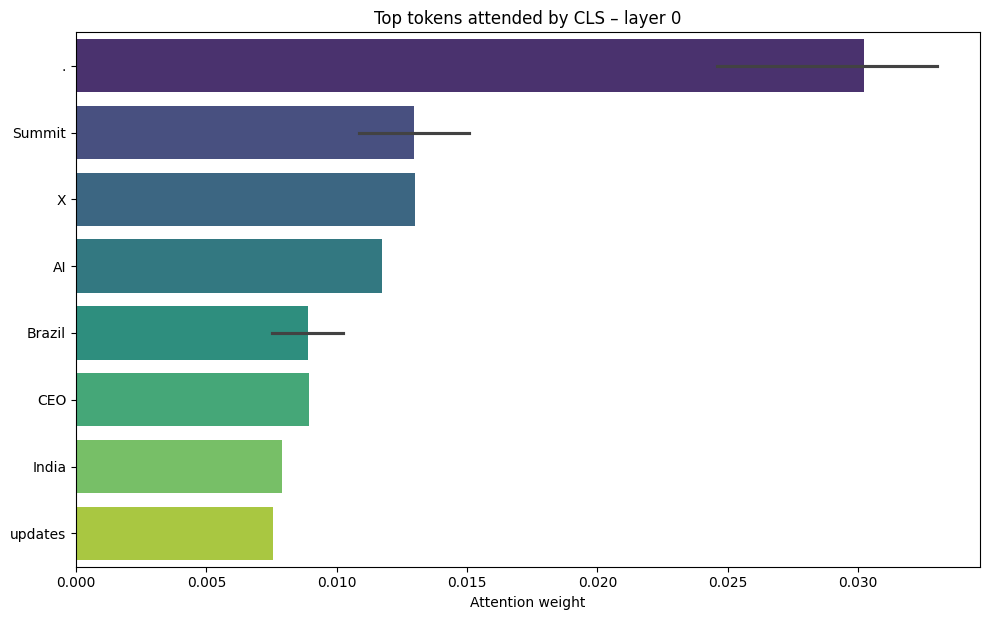

In [62]:
show_prediction(text)
show_attention(text, layer=-1, top_k_tokens=18)

C:\Users\GYANENDRA\AppData\Local\Temp\ipykernel_20716\2980508986.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_tokens, palette="viridis")


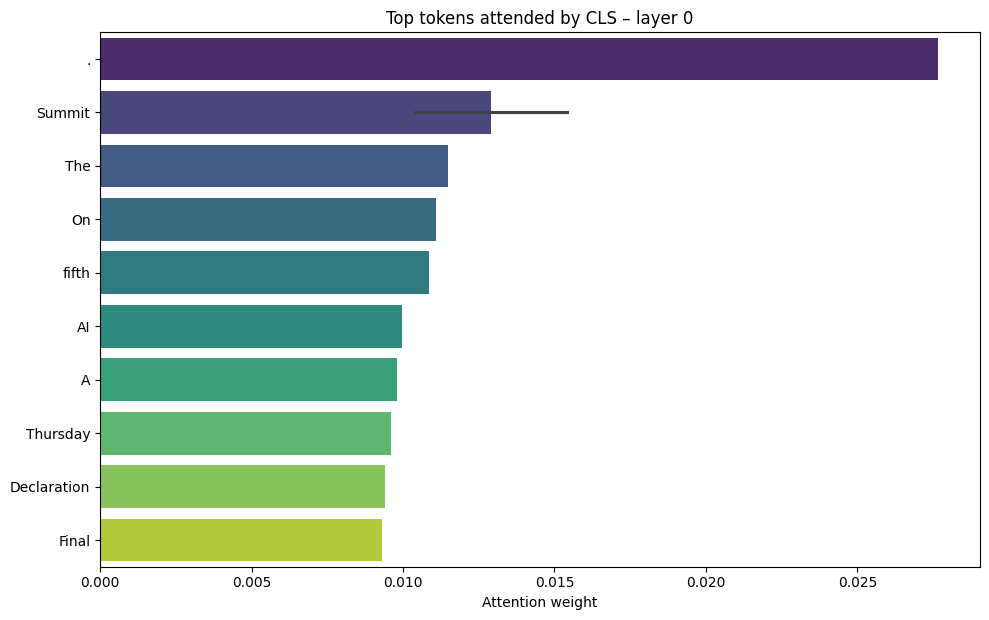

In [63]:
show_prediction(positive_tone_text)
show_attention(positive_tone_text, layer=-1, top_k_tokens=18)

C:\Users\GYANENDRA\AppData\Local\Temp\ipykernel_20716\2980508986.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_tokens, palette="viridis")


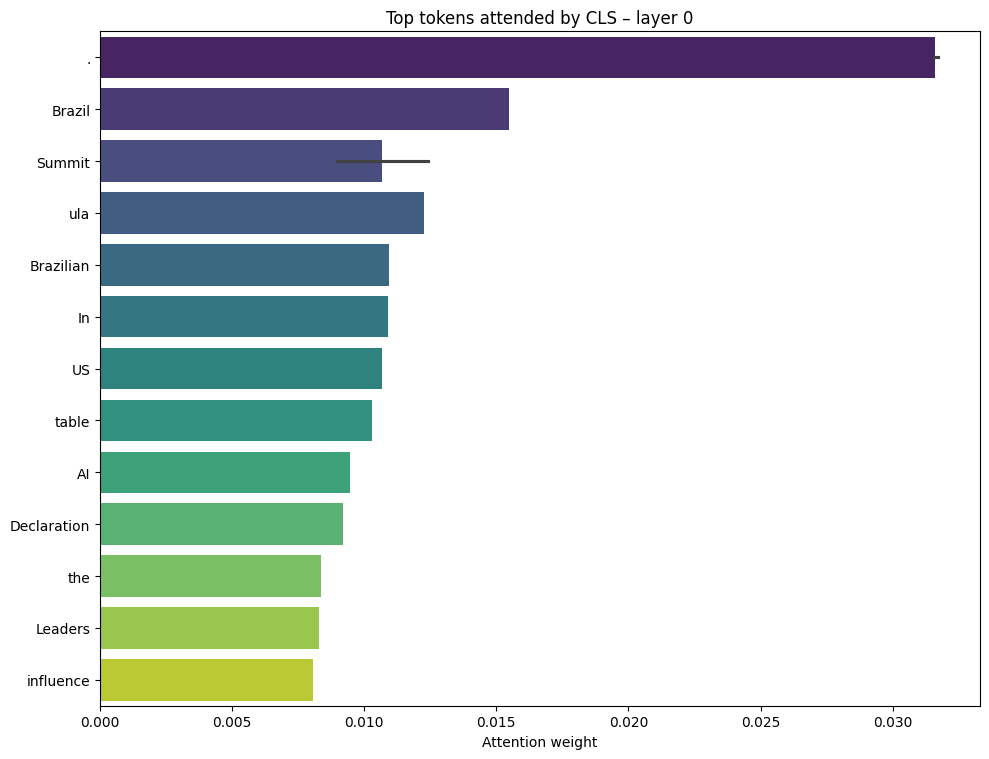

In [64]:
show_prediction(negative_tone_text)
show_attention(negative_tone_text, layer=-1, top_k_tokens=22)

C:\Users\GYANENDRA\AppData\Local\Temp\ipykernel_20716\2980508986.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_values, y=top_tokens, palette="viridis")


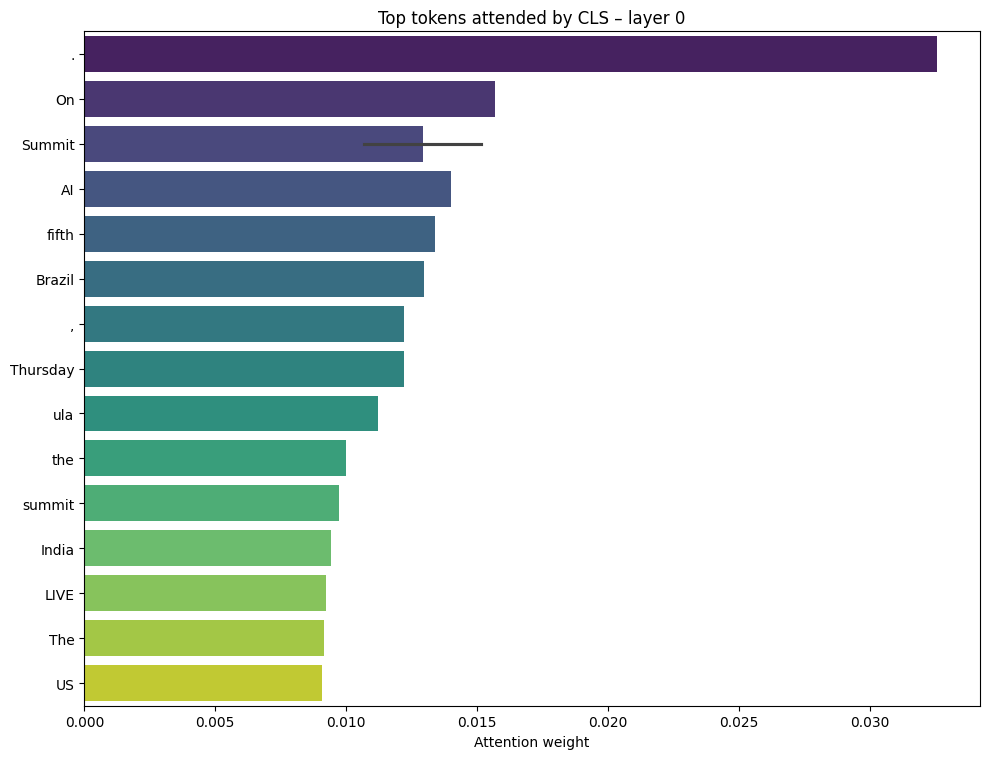

In [65]:
show_prediction(neutral_tone_text)
show_attention(neutral_tone_text, layer=-1, top_k_tokens=22)